In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, simpson
from nbodykit import cosmology
import astropy.cosmology as ap
from astropy import units as u
from astropy.constants import c as slight
from tqdm import tqdm

### Set up cosmological data
using nbodykit for the non-linear matter power spectrum (HalofitPower) and astropy for computing other cosmological parameters like comoving distance. Astropy and nbodykit use the same data and are largly compatible with each other.

In [2]:
cosmo = cosmology.Cosmology()
astro_cos = ap.Planck15
c = cosmology.Planck15

In [3]:
c = c.clone(z_max_pk=1080, P_k_max=4000, nonlinear=True)

In [4]:
Pnl = cosmology.HalofitPower(c, redshift=0)

In [5]:
k = 10**np.linspace(-3.0, 3, 500)
Pnl.redshift = 0
Pk1 = Pnl(k)
Pnl.redshift=5
Pk2 = Pnl(k)

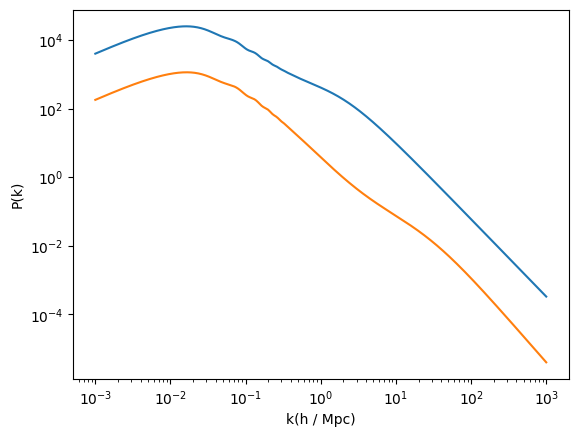

In [6]:
plt.figure()
plt.loglog()
plt.xlabel('k(h / Mpc)')
plt.ylabel('P(k)')
plt.plot(k, Pk1, '-')
plt.plot(k, Pk2, '-')


#### Set up kernal and window function (galaxy distribution)


In [50]:
class gL():
    def __init__(self, z0, dz):
        self.z0 = z0
        self.dz = dz
        self.set_comoving_distances()

    def set_comoving_distances(self):
        self.chi0 = astro_cos.comoving_distance(self.z0).value
        self.dchi = astro_cos.comoving_distance(self.dz).value
        
    def gaussianW(self,chi, chi1):
        """
        A gaussian galaxy distrubution in co-moving distance given a central z value and some width dz

        return: value of g_L
        return type: float
        """
        
        gaussian = np.exp(-(chi - self.chi0)**2 / (2 * self.dchi**2)) / (np.sqrt(2*np.pi*self.dchi**2))
        result = (1 - chi1 / chi) * gaussian
        return result

    def tophat(self, chi, chi1):
        """
        Tophat distribution for lensed galaxies, with the tophat between chi0 and dchi.

        returns: value of g_L at chi given chi1.
        return type: float
        """

        result = (1- chi1/chi) / np.abs(self.chi0 - self.dchi) if chi > self.chi0 and chi < self.dchi else 0
        return result

    def delta(self, chi):
        return 2* np.pi * (1-chi1/self.chi0) / self.chi0 if chi1 < self.chi0 else 0

    def __call__(self, chi1, window="gaussian"):
        intarr = []
        if window == "gaussian":
            chiarr = np.linspace(chi1, self.chi0 + 100*self.dchi,1000)
            for chi in chiarr:
                intarr += [self.gaussianW(chi, chi1)]
                
        elif window == 'tophat':
            chiarr = np.linspace(chi1, self.dchi, 500)
            for chi in chiarr:
                intarr += [self.tophat(chi, chi1)]
                
        else:
            chiarr = np.linspace(chi1, self.dchi, 500)
            for chi in chiarr:
                intarr += [self.delta(chi)]

        return simpson(intarr, chiarr)   # quad(self.integrand, chi1, np.inf, args=(chi1))[0] 

In [51]:
gaussian_gL = gL(1080,1080)

Text(0, 0.5, '$g_L(\\chi)$')

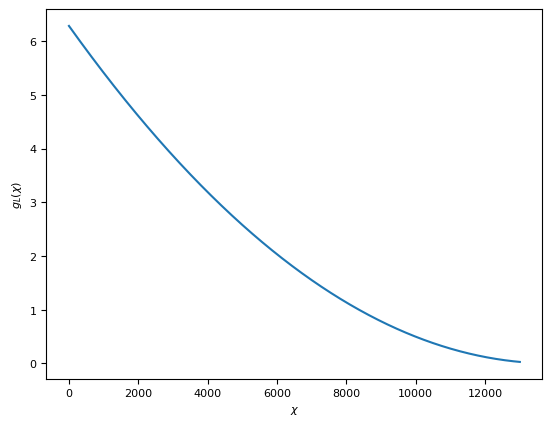

In [52]:
chi1Arr = np.linspace(0, 13000, 1000)
yarr = []
errarr = []
for chi1 in chi1Arr:
    integral = gaussian_gL(chi1, window='delta')
    yarr += [integral]
plt.plot(chi1Arr, yarr)
plt.xlabel(r'$\chi$')
plt.ylabel(r'$g_L(\chi)$')


#### create functions for the power spectrum from Pnl and gL

In [53]:
def int_converg_powerSpectrum(z,l):
    chi = astro_cos.comoving_distance(z).value  # [Mpc]
    
    Pnl.redshift = z
    
    const = (3 * (astro_cos.H(0).to(1/u.s))**2 * astro_cos.Om0 / 2)**2 / slight.to(u.Mpc/u.s)**3  # [1/sec * Mpc^3]
    
    gl =  gaussian_gL(chi, window='delta')
    
    result = (const * gl * (1+z)**2 * Pnl((l/chi)) / astro_cos.H(z).to(1/u.s)).value  # unitless, [Pnl] = Mpc^3, [1/H(z)] = sec
    return result

def converg_powerSpec(l, zmin=0.005, zmax=1080):
    zpts = np.linspace(zmin, zmax, 5000)
    powerSpecPts = []
    for z in zpts:
        powerSpecPts += [int_converg_powerSpectrum(z, l)]
    res = simpson(powerSpecPts, zpts)  # quad(int_converg_powerSpectrum, zmin,zmax, args=(l))[0] 
    return res

In [54]:
l=60
zpts = np.linspace(0.001, 1080, 5000)
powerSpecPts = []
for z in zpts:
    pt = int_converg_powerSpectrum(z, l)
    powerSpecPts += [pt]

Text(0, 0.5, '$\\propto \\frac{g_L(z)P(l,z)}{H(z)}$')

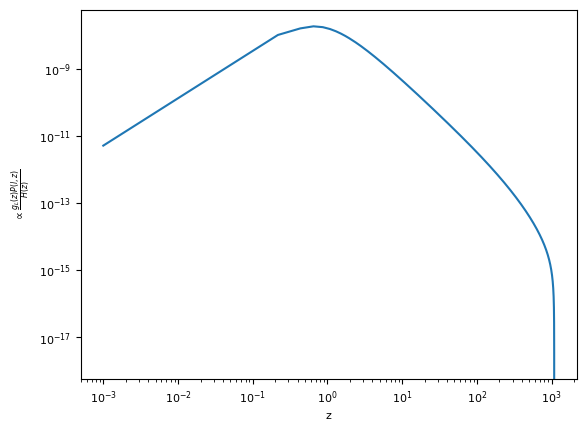

In [55]:
plt.loglog(zpts, powerSpecPts)
plt.xlabel('z')
plt.ylabel(r'$\propto \frac{g_L(z)P(l,z)}{H(z)}$')

#### Iterate from l=1 to l = 10^4.8 (similar bounds as in figure 13.7 in Modern Cosmology second edition)

In [56]:
lArr = np.logspace(0, 4.8, 75)
powerArr = []
for l in tqdm(lArr):
    powerArr += [l*(l+1) * converg_powerSpec(l)/(2*np.pi)]

100%|███████████████████████████████████████████| 75/75 [05:59<00:00,  4.80s/it]


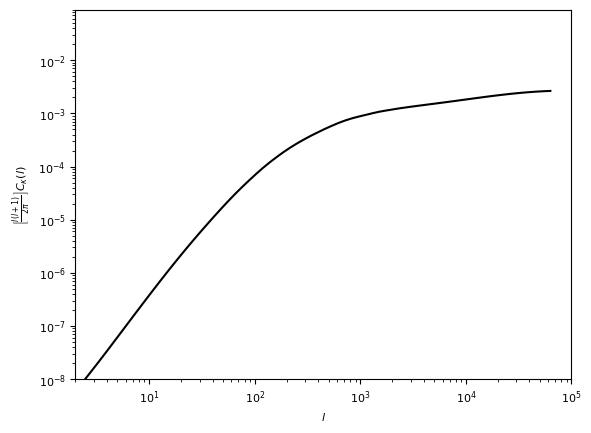

In [57]:
fig, ax = plt.subplots()
#ax.scatter(lArr, powerArr,s=5, c='red')

ax.loglog(lArr, np.array(powerArr), c='k')
ax.set_xlabel(r'$l$')
ax.set_ylabel(r'$\left[\frac{l(l+1)}{2\pi}\right]C_\kappa(l)$')
ax.set_ylim(10**-8, 9 * 10**-2)
ax.set_xlim(2, 10**5)
plt.show()

In [58]:
np.savez("Planck15_deltaWindow_cmb.npz", l=np.array(lArr), power=np.array(powerArr))

### Plot several different distribution functions

In [59]:
gaus_data2 = np.load("Planck15_gaussianWindow_2_0.2.npz")
tophat_data = np.load("Planck15_tophatWindow_1_4.npz")
cmb = np.load("Planck15_deltaWindow_cmb.npz")

In [60]:
plt.rcdefaults()

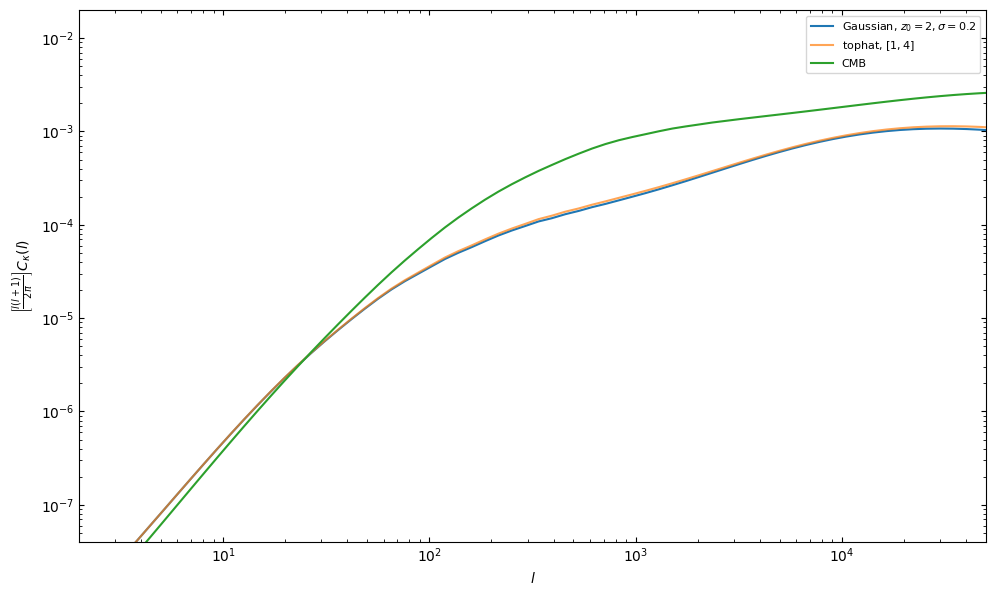

In [61]:
fig,ax = plt.subplots(figsize=(10,6))
font = {'size'   : 8}

plt.rc('font', **font)
ax.loglog(gaus_data2["l"], gaus_data2['power'], label=r'Gaussian, $z_0=2, \sigma=0.2$')
ax.loglog(tophat_data['l'], tophat_data['power'], label='tophat, $[1,4]$', alpha=0.7)
ax.loglog(cmb['l'], cmb['power'], label="CMB")

#ax.axvline(20, linestyle="dotted", c='k')  # for reference to where l=20

ax.set_xlabel(r'$l$')
ax.set_ylabel(r'$\left[\frac{l(l+1)}{2\pi}\right]C_\kappa(l)$')
ax.legend()
ax.set_ylim(4 * 10**-8, 2 * 10**-2)
ax.set_xlim(2, 5 * 10**4)
ax.tick_params(which='major', right=True, top=True, labeltop=False, bottom=True, labelbottom=True, direction="in")
ax.tick_params(which='minor', right=True, top=True, labeltop=False, bottom=True, labelbottom=True, direction="in")
plt.tight_layout()
plt.savefig("PowerSpec_Planck15_figure.png")